#Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv('/content/Medicaldataset.csv')

In [3]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [4]:
df.tail()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive
1318,51,1,94,157,79,134.0,50.89,1.770,positive


In [5]:
df['Gender'].unique()

array([1, 0])

In [6]:
df['Result'].unique()

array(['negative', 'positive'], dtype=object)

#Data pre-processing

In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Result"] = le.fit_transform(df["Result"])

In [9]:
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0


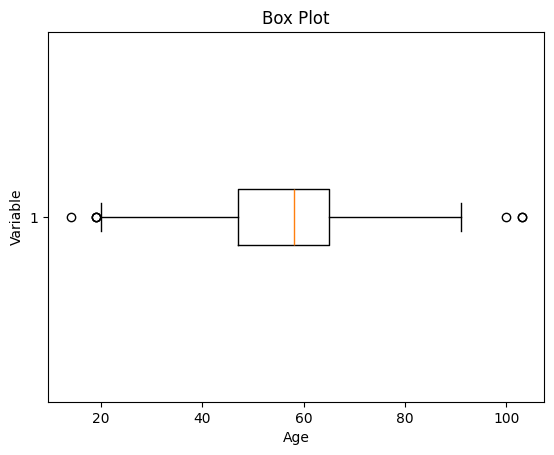

In [10]:
plt.boxplot(df['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Age")
plt.title('Box Plot')
plt.show()

Lower Bound : 28.89718102661417
Upper Bound : 83.48644293092943


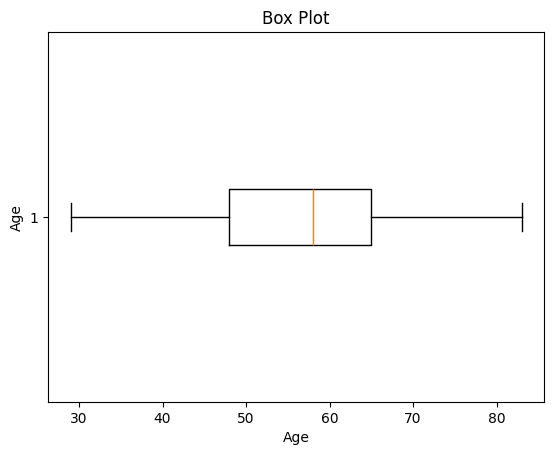

In [11]:
mean = df['Age'].mean()
std  = df['Age'].std()


lower_bound = mean - std*2
upper_bound = mean + std*2

print('Lower Bound :',lower_bound)
print('Upper Bound :',upper_bound)


df = df[(df['Age'] >= lower_bound)
                & (df['Age'] <= upper_bound)]
plt.boxplot(df['Age'], vert=False)
plt.ylabel('Age')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

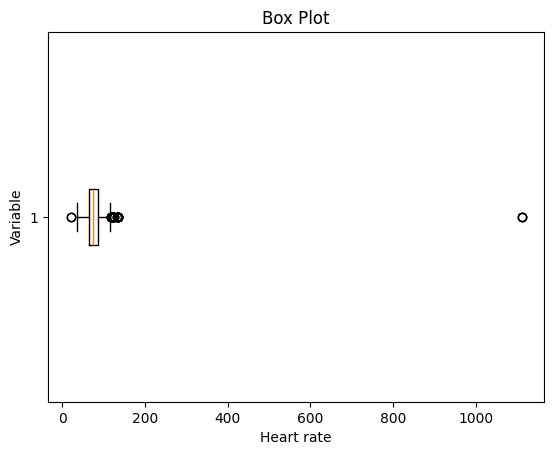

In [12]:
plt.boxplot(df['Heart rate'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Heart rate")
plt.title('Box Plot')
plt.show()

In [13]:
df['Heart rate'].describe()

,Heart rate
count,1259.000000
mean,78.482129
std,52.726733
min,20.000000
25%,64.000000
50%,74.000000
75%,85.000000
max,1111.000000


In [14]:
df['Heart rate'] = df['Heart rate'].clip(lower=30, upper=220)

In [15]:
df['Heart rate'].describe()

,Heart rate
count,1259.000000
mean,76.374901
std,16.714403
min,30.000000
25%,64.000000
50%,74.000000
75%,85.000000
max,220.000000


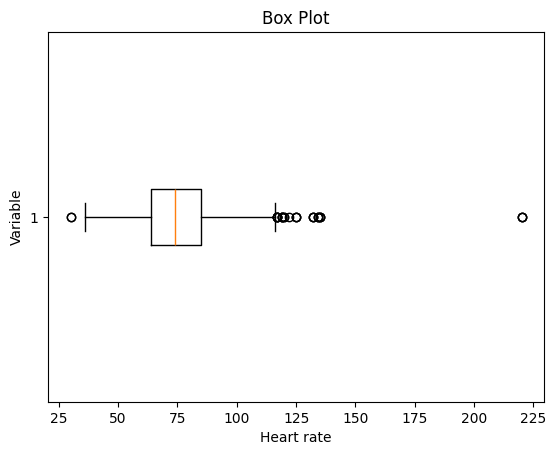

In [16]:
plt.boxplot(df['Heart rate'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Heart rate")
plt.title('Box Plot')
plt.show()

In [17]:
Q1 = df['Heart rate'].quantile(0.25)
Q3 = df['Heart rate'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

df = df[(df['Heart rate'] >= lower_bound) & (df['Heart rate'] <= upper_bound)]


Lower bound: 32.5
Upper bound: 116.5


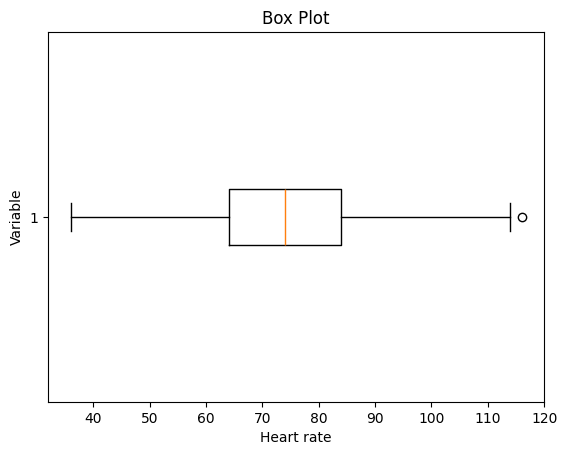

In [18]:
plt.boxplot(df['Heart rate'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Heart rate")
plt.title('Box Plot')
plt.show()

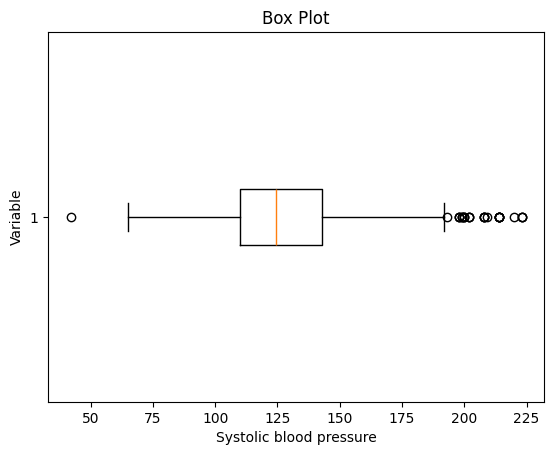

In [19]:
plt.boxplot(df['Systolic blood pressure'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Systolic blood pressure")
plt.title('Box Plot')
plt.show()

In [20]:
df = df[df['Systolic blood pressure'].between(70, 200)]

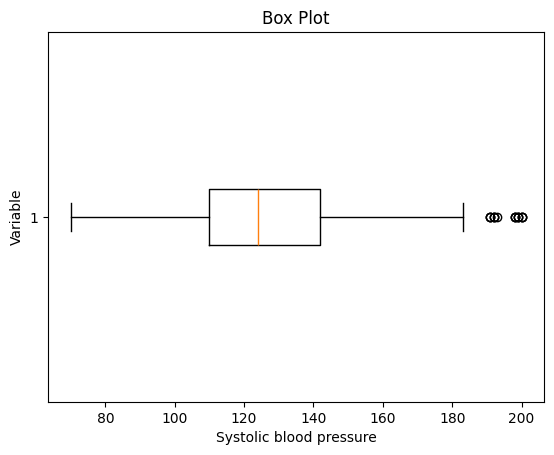

In [21]:
plt.boxplot(df['Systolic blood pressure'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Systolic blood pressure")
plt.title('Box Plot')
plt.show()

In [22]:
df['Systolic blood pressure'].describe()

,Systolic blood pressure
count,1206.000000
mean,126.307629
std,23.459524
min,70.000000
25%,110.000000
50%,124.000000
75%,142.000000
max,200.000000


Lower Bound : 79.3885803854426
Upper Bound : 173.22667666265028


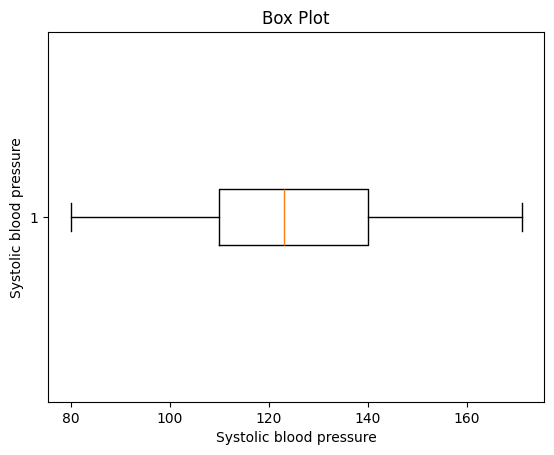

In [23]:
mean = df['Systolic blood pressure'].mean()
std  = df['Systolic blood pressure'].std()


lower_bound = mean - std*2
upper_bound = mean + std*2

print('Lower Bound :',lower_bound)
print('Upper Bound :',upper_bound)

# Drop the outliers
df = df[(df['Systolic blood pressure'] >= lower_bound)
                & (df['Systolic blood pressure'] <= upper_bound)]
plt.boxplot(df['Systolic blood pressure'], vert=False)
plt.ylabel('Systolic blood pressure')
plt.xlabel('Systolic blood pressure')
plt.title('Box Plot')
plt.show()

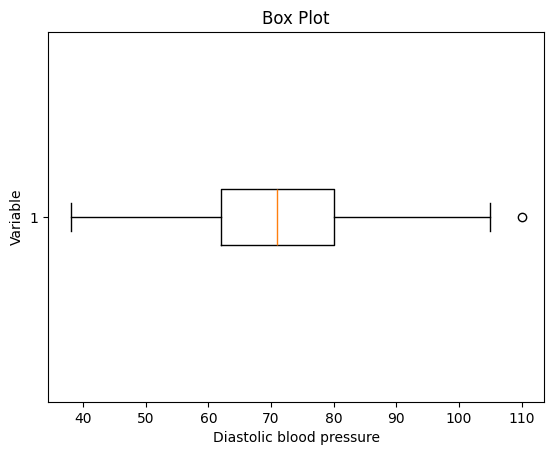

In [24]:
plt.boxplot(df['Diastolic blood pressure'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Diastolic blood pressure")
plt.title('Box Plot')
plt.show()

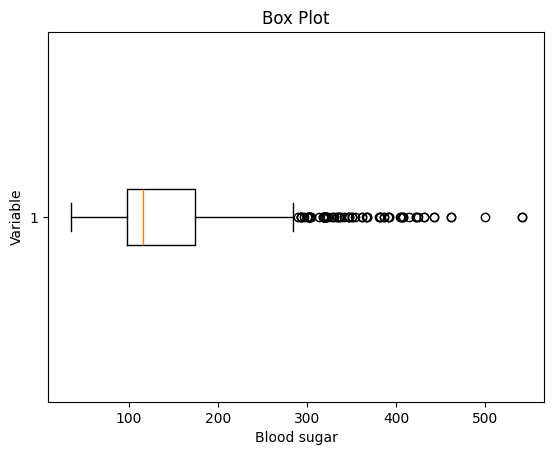

In [25]:
plt.boxplot(df['Blood sugar'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Blood sugar")
plt.title('Box Plot')
plt.show()

In [26]:
df['Blood sugar'].describe()

,Blood sugar
count,1159.000000
mean,147.369888
std,75.375952
min,35.000000
25%,98.000000
50%,116.000000
75%,174.500000
max,541.000000


In [27]:
Q1 = df['Blood sugar'].quantile(0.25)
Q3 = df['Blood sugar'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

df = df[(df['Blood sugar'] >= lower) & (df['Blood sugar'] <= upper)]


-16.75 289.25


In [28]:
df['Blood sugar'].describe()

,Blood sugar
count,1083.000000
mean,132.494645
std,49.714863
min,35.000000
25%,97.000000
50%,114.000000
75%,156.500000
max,285.000000


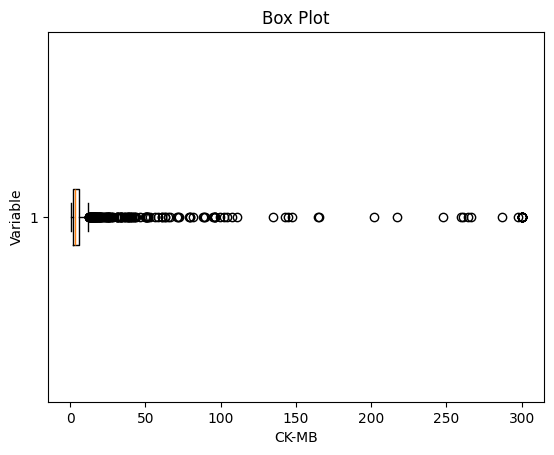

In [29]:
plt.boxplot(df['CK-MB'], vert=False)
plt.ylabel('Variable')
plt.xlabel("CK-MB")
plt.title('Box Plot')
plt.show()

In [30]:
df['CK-MB'].describe()

,CK-MB
count,1083.000000
mean,13.968181
std,42.901362
min,0.321000
25%,1.660000
50%,2.900000
75%,5.805000
max,300.000000


In [31]:
df = df[df['CK-MB'].between(0, 100)]

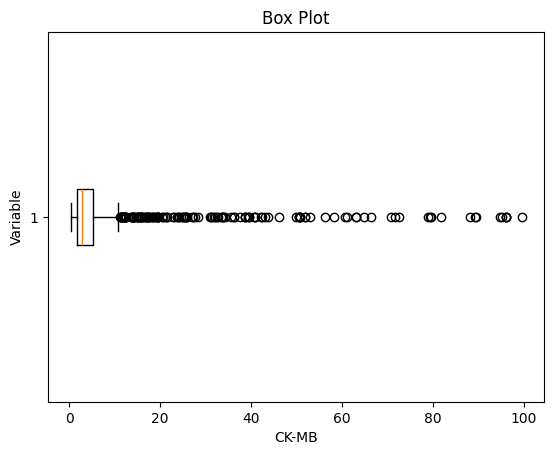

In [32]:
plt.boxplot(df['CK-MB'], vert=False)
plt.ylabel('Variable')
plt.xlabel("CK-MB")
plt.title('Box Plot')
plt.show()

In [33]:
df['CK-MB'].describe()

,CK-MB
count,1051.000000
mean,7.231722
std,13.815391
min,0.321000
25%,1.640000
50%,2.840000
75%,5.330000
max,99.560000


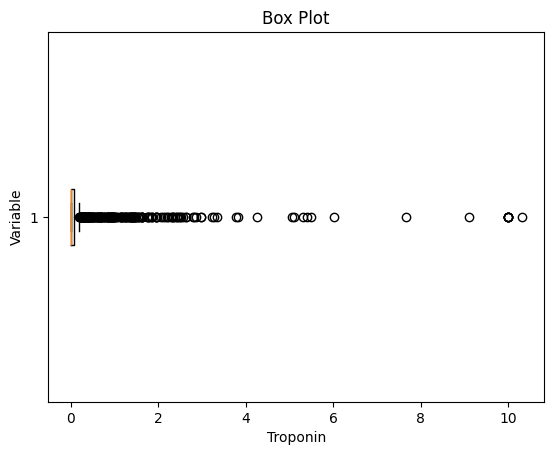

In [34]:
plt.boxplot(df['Troponin'], vert=False)
plt.ylabel('Variable')
plt.xlabel("Troponin")
plt.title('Box Plot')
plt.show()

In [35]:
df['Troponin'].describe()

,Troponin
count,1051.000000
mean,0.340099
std,1.106817
min,0.003000
25%,0.006000
50%,0.015000
75%,0.084000
max,10.300000


In [36]:
Q1 = df['Troponin'].quantile(0.25)
Q3 = df['Troponin'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

df = df[(df['Troponin'] >= lower) & (df['Troponin'] <= upper)]

-0.11099999999999999 0.201


In [37]:
df['Troponin'].describe()

,Troponin
count,850.000000
mean,0.024264
std,0.036155
min,0.003000
25%,0.005000
50%,0.010000
75%,0.024000
max,0.200000


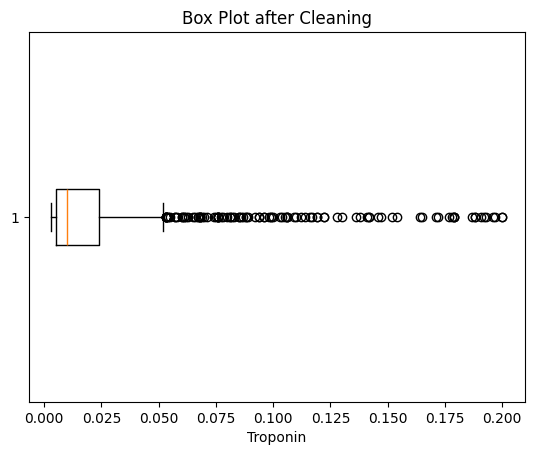

In [38]:
plt.boxplot(df['Troponin'], vert=False)
plt.xlabel('Troponin')
plt.title('Box Plot after Cleaning')
plt.show()

In [39]:
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Test 1
NN before Scaling

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [41]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
history=model.fit(X_train, y_train, epochs=50, batch_size=20, validation_data=(X_test, y_test))

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4797 - loss: 9.2448 - val_accuracy: 0.5353 - val_loss: 2.9661
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5216 - loss: 4.0230 - val_accuracy: 0.5176 - val_loss: 1.7596
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5273 - loss: 2.5880 - val_accuracy: 0.5176 - val_loss: 0.9786
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5468 - loss: 1.9629 - val_accuracy: 0.5941 - val_loss: 0.7031
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5425 - loss: 1.6077 - val_accuracy: 0.5529 - val_loss: 0.9316
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5673 - loss: 1.6015 - val_accuracy: 0.6059 - val_loss: 0.6732
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5815 - loss: 1.1271 - val_accuracy: 0.6000 - val_loss: 0.7084
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5712 - loss: 1.0645 - val_accuracy: 0.6059 - val_loss:

Higesht accuracy achived ≈ 60-70

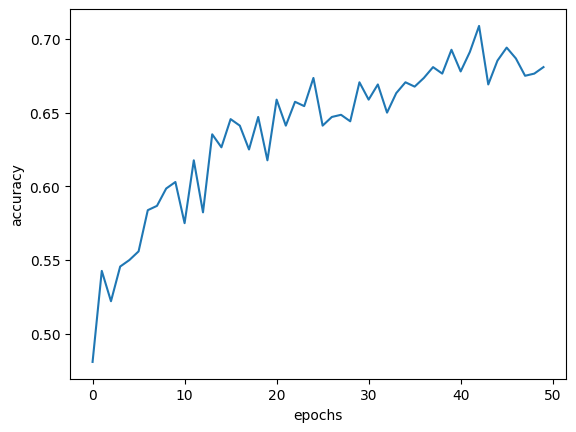

In [44]:
plt.plot(history.history['accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.show()

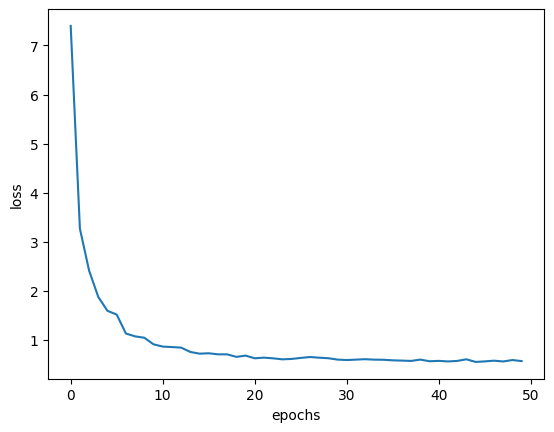

In [45]:
plt.plot(history.history['loss'])
plt.ylabel('loss')
plt.xlabel('epochs')
plt.show()

#Test 2
NN after Scaling

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [49]:
history=model.fit(X_train, y_train, epochs=50, batch_size=30, validation_data=(X_test, y_test))

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5226 - loss: 0.6997 - val_accuracy: 0.6529 - val_loss: 0.6443
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6667 - loss: 0.6196 - val_accuracy: 0.7647 - val_loss: 0.5905
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7647 - loss: 0.5589 - val_accuracy: 0.7941 - val_loss: 0.5402
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7820 - loss: 0.5099 - val_accuracy: 0.8176 - val_loss: 0.4904
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8411 - loss: 0.4611 - val_accuracy: 0.8235 - val_loss: 0.4492
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8364 - loss: 0.4055 - val_accuracy: 0.8235 - val_loss: 0.4119
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8442 - loss: 0.3998 - val_accuracy: 0.8471 - val_loss: 0.3743
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8415 - loss: 0.3799 - val_accuracy: 0.8765 - val_loss:

Higesht accuracy achived ≈ 95

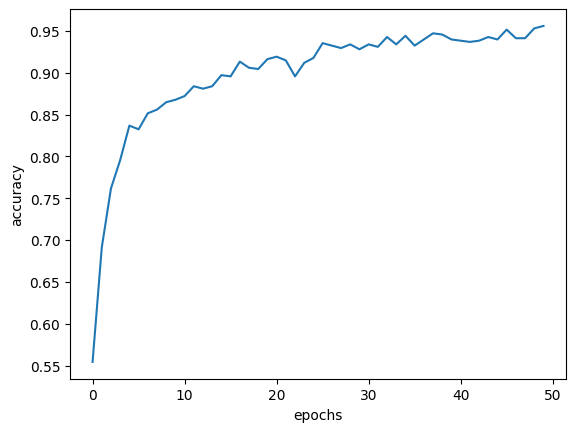

In [50]:
plt.plot(history.history['accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.show()

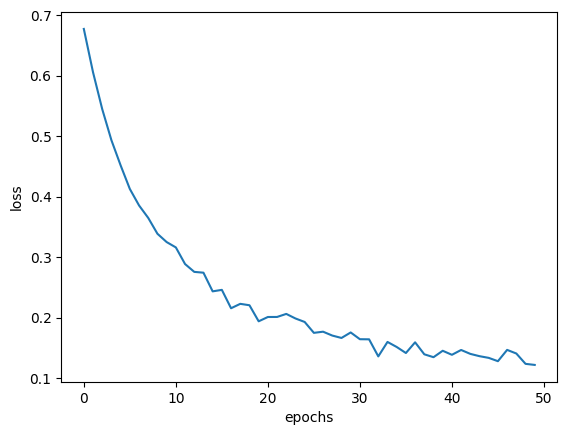

In [51]:
plt.plot(history.history['loss'])
plt.ylabel('loss')
plt.xlabel('epochs')
plt.show()

#Test 3
svm

In [52]:
model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8588235294117647

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.94      0.86        81
           1       0.93      0.79      0.85        89

    accuracy                           0.86       170
   macro avg       0.87      0.86      0.86       170
weighted avg       0.87      0.86      0.86       170


Confusion Matrix:
 [[76  5]
 [19 70]]


 Highest accuracy ≈ 86

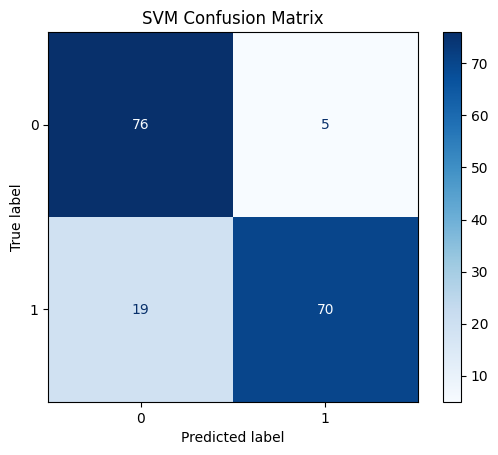

In [53]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

#Test 4
Random Forest


In [54]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        81
           1       0.99      0.98      0.98        89

    accuracy                           0.98       170
   macro avg       0.98      0.98      0.98       170
weighted avg       0.98      0.98      0.98       170



 Highest accuracy ≈ 98

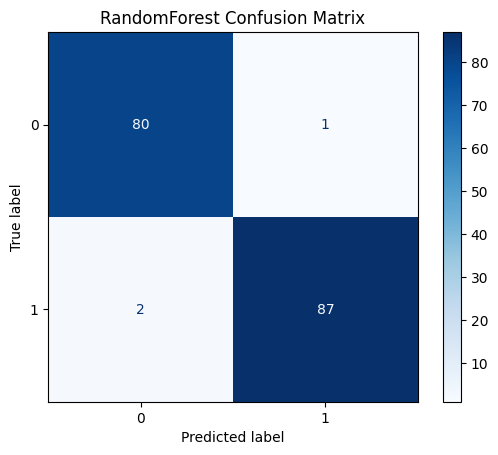

In [55]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('RandomForest Confusion Matrix')
plt.show()

#Final test

In [56]:
import statsmodels.api as sm

# Assume X is your feature DataFrame and y is your target
X = sm.add_constant(X)  # adds the intercept term
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Result   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     54.19
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           5.96e-71
Time:                        17:49:53   Log-Likelihood:                -439.38
No. Observations:                 850   AIC:                             896.8
Df Residuals:                     841   BIC:                             939.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [57]:
#Linear correlation
df.corr()['Result'][['Diastolic blood pressure', 'Systolic blood pressure','Heart rate']]

,Result
Diastolic blood pressure,-0.038018
Systolic blood pressure,-0.069911
Heart rate,-0.028296


In [58]:
df = df.drop(['Diastolic blood pressure', 'Systolic blood pressure','Heart rate'], axis=1)


In [59]:
df.head()

,Age,Gender,Blood sugar,CK-MB,Troponin,Result
0,64,1,160.0,1.80,0.012,0
2,55,1,270.0,1.99,0.003,0
3,64,1,270.0,13.87,0.122,1
5,58,0,87.0,1.83,0.004,0
8,44,0,135.0,2.35,0.004,0


In [60]:
X = df.drop('Result', axis=1)
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
X

,Age,Gender,Blood sugar,CK-MB,Troponin
0,64,1,160.0,1.80,0.012
2,55,1,270.0,1.99,0.003
3,64,1,270.0,13.87,0.122
5,58,0,87.0,1.83,0.004
8,44,0,135.0,2.35,0.004
...,...,...,...,...,...
1303,55,0,200.0,0.78,0.052
1306,60,0,230.0,19.47,0.003
1312,48,1,96.0,5.33,0.006
1314,44,1,204.0,1.63,0.006


In [62]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        81
           1       0.99      0.98      0.98        89

    accuracy                           0.98       170
   macro avg       0.98      0.98      0.98       170
weighted avg       0.98      0.98      0.98       170



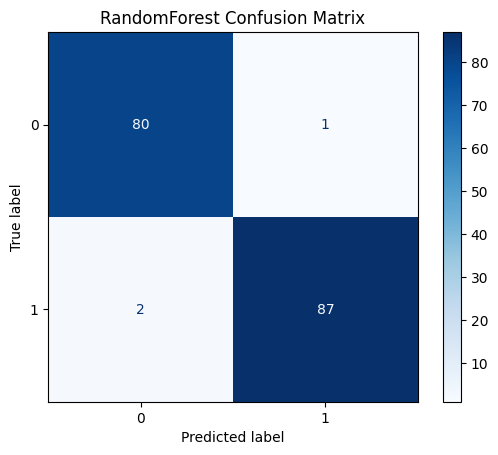

In [63]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('RandomForest Confusion Matrix')
plt.show()